In [1]:
chain_path = 'chains/des-y3-maglim-2x2pt-nautilus-pca.txt'
import utils
samples = utils.read_samples_from_chain(chain_path=chain_path, burnin=0.5)

Removed 0.5 as burn in


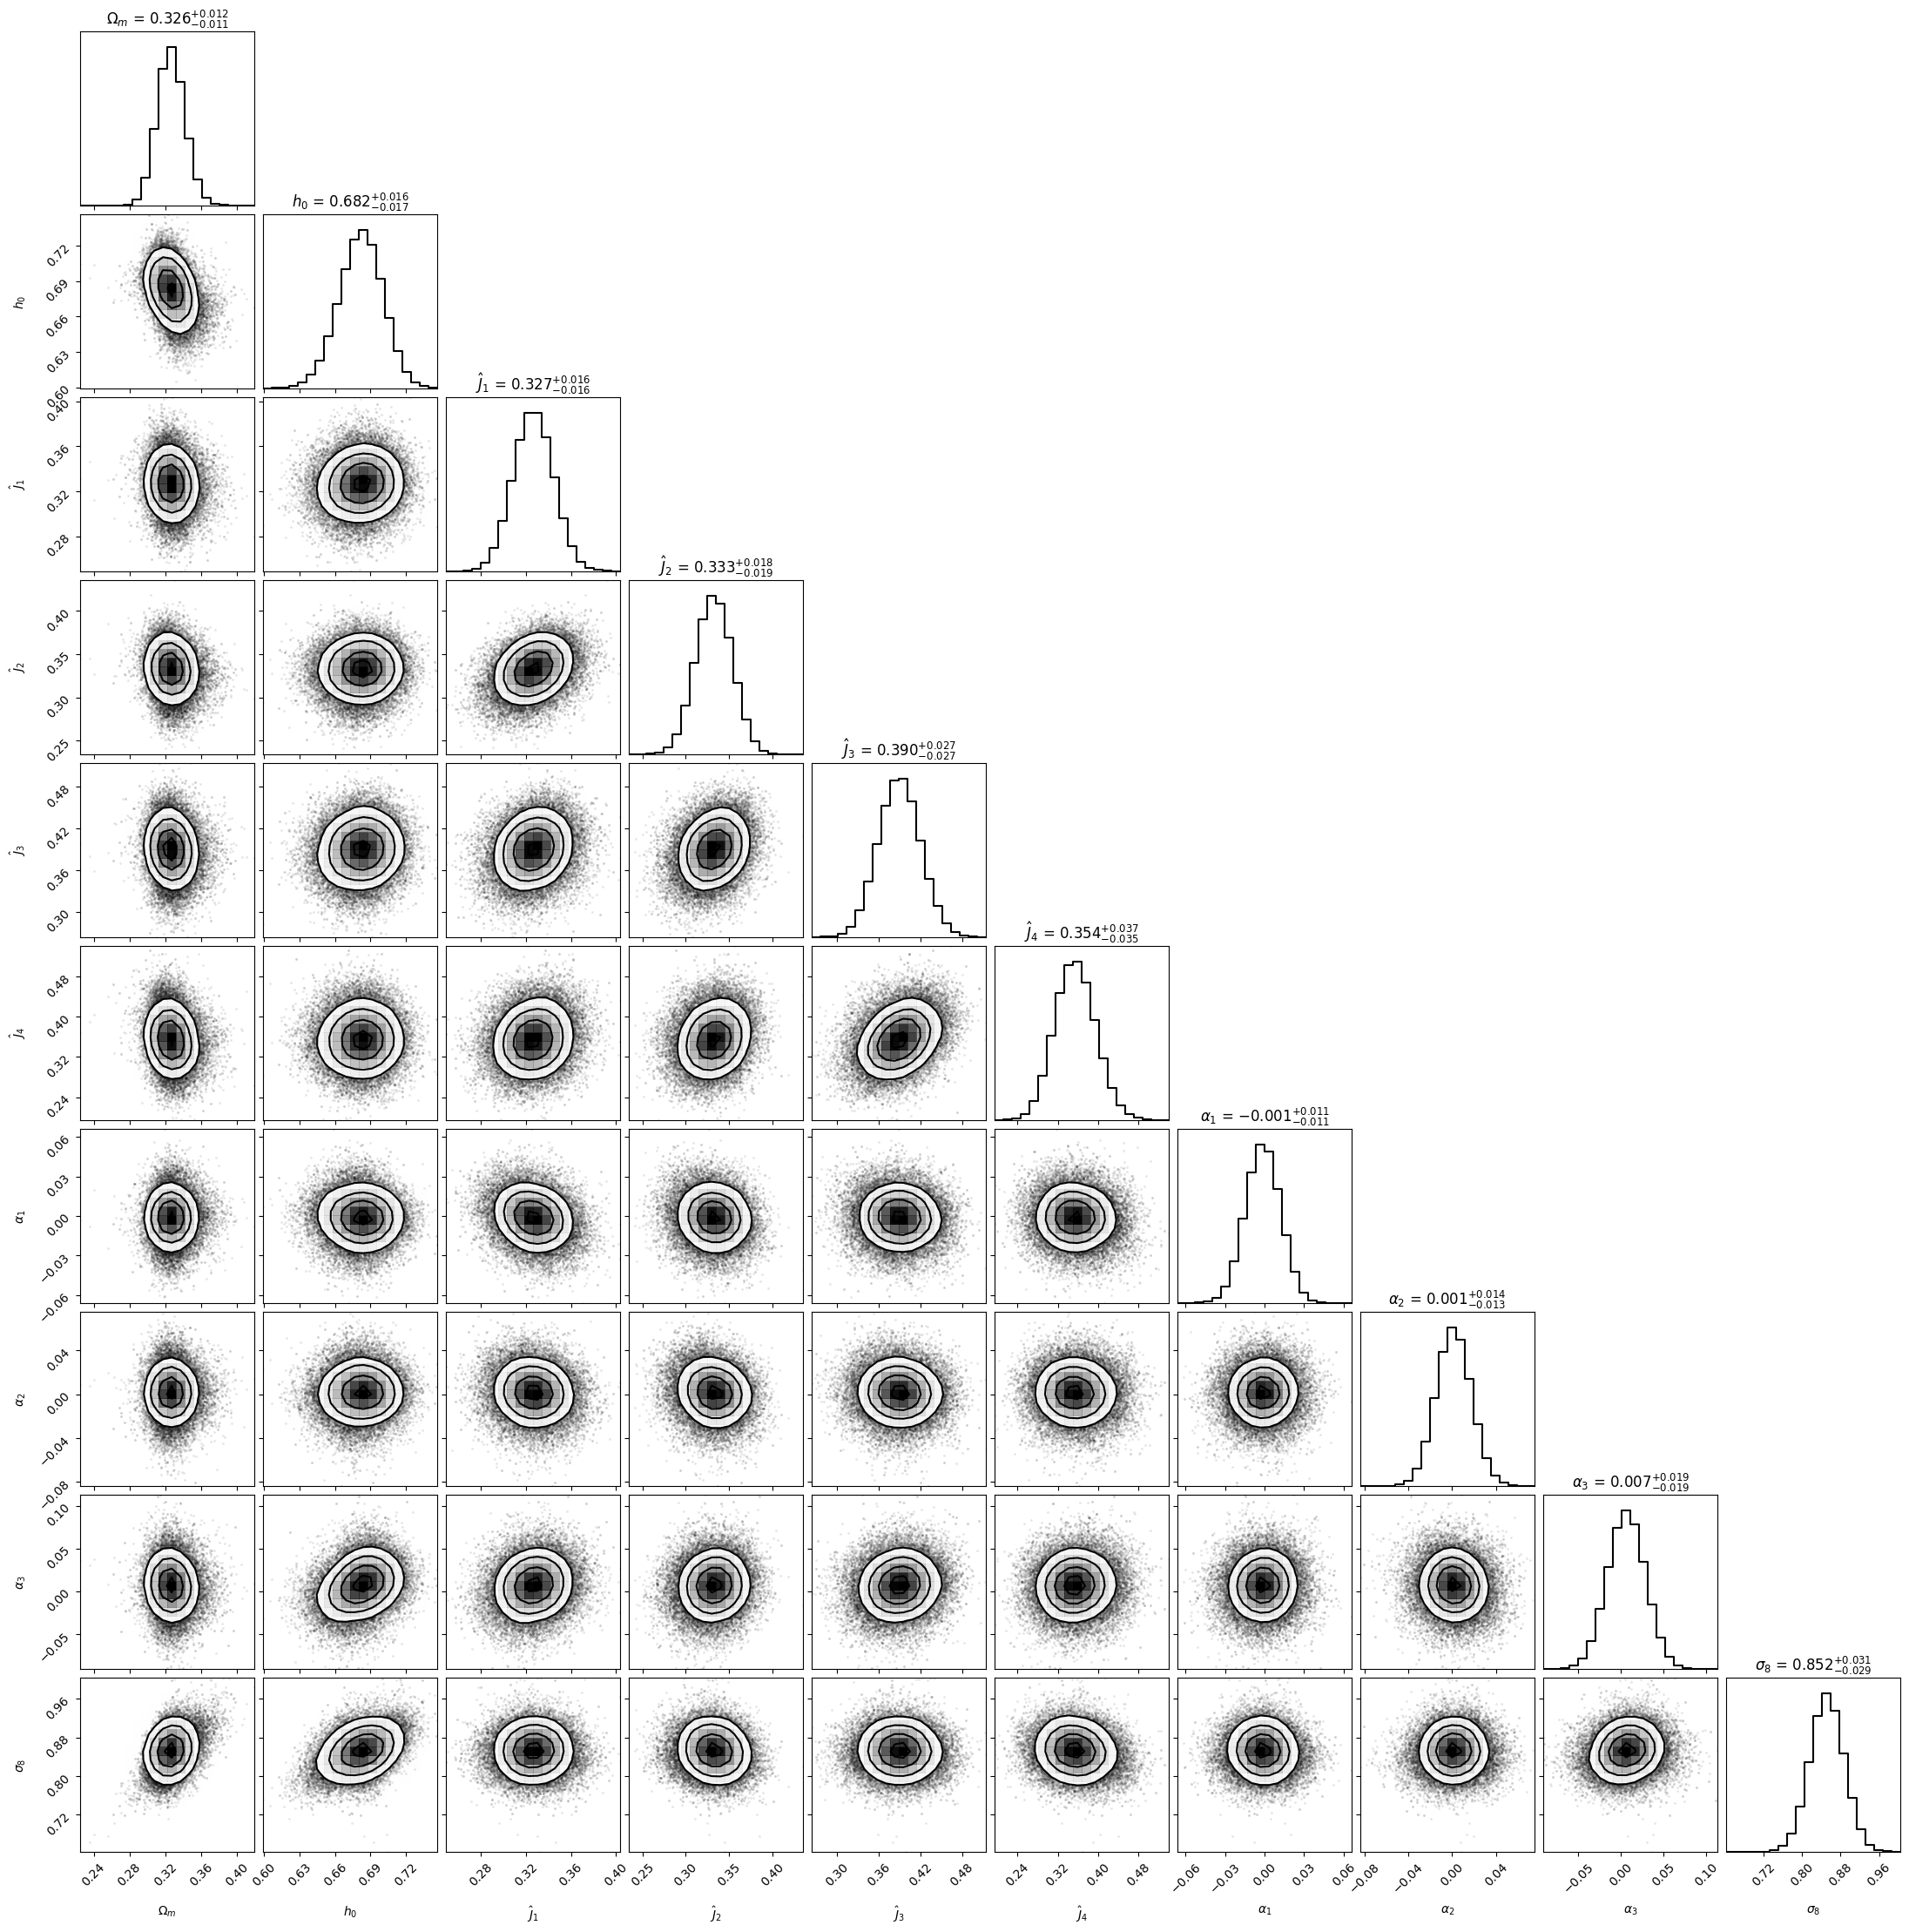

In [2]:
# get chain and plot corner
import corner
import numpy as np
import matplotlib.pyplot as plt

all_data = np.loadtxt(chain_path, skiprows=1)
burnin = int(0.5 * len(all_data))
data = all_data[burnin:]
data = data[~np.isnan(data).any(axis=1)]
log_weights = data[:, -3]
weights = np.exp(log_weights - np.max(log_weights))

columns_to_plot = data[:, [0, 1, 23, 24, 25, 26, 27, 28, 29, 34]]

labels = [r"$\Omega_m$", r"$h_0$" ,r"$\hat{J}_1$",r"$\hat{J}_2$",r"$\hat{J}_3$",r"$\hat{J}_4$",r"$\alpha_1$",r"$\alpha_2$",r"$\alpha_3$",r"$\sigma_8$"]

fig = corner.corner(
    columns_to_plot,
    labels=labels,
    weights = weights,
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 12},
    smooth=1,
    smooth1d=1
)
plt.show()

In [3]:
import emcee
tau = emcee.autocorr.integrated_time(data[:,23])
print("Autocorrelation time for J1:", tau)
N_steps = len(data[:,23])
N_eff = N_steps / tau
print("Effective sample size for J1:", N_eff)

Autocorrelation time for J1: [1.04584069]
Effective sample size for J1: [45815.77324308]


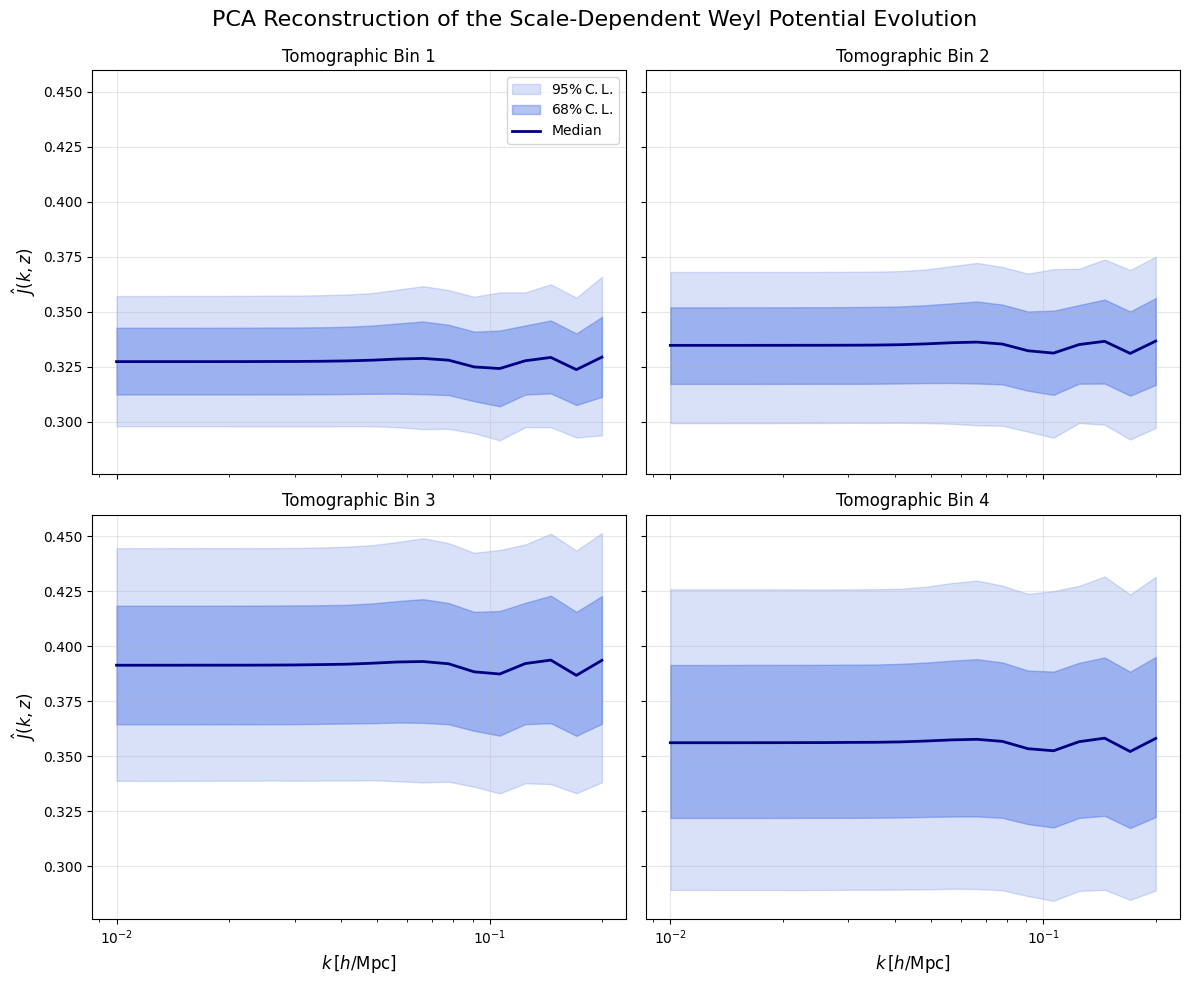

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_and_plot_Jk(samples, pca_mode_file, z_bins=4, n_modes=3):
    if hasattr(samples, 'samples'):
        samples = samples.samples
    p_J_amps = samples[:, [23, 24, 25, 26]]
    p_alphas = samples[:, [27, 28, 29]]
    
    n_samples = len(samples)

    data_pca = np.loadtxt(pca_mode_file)
    k_grid = data_pca[:, 0]
    modes = data_pca[:, 1:n_modes+1]
    
    n_k = len(k_grid)

    Jk_reconstructed = np.zeros((z_bins, n_samples, n_k))
    
    for i in range(n_samples):
        shape_factor = 1.0 + np.sum(p_alphas[i, :] * modes, axis=1)
        
        for z in range(z_bins):
            Jk_reconstructed[z, i, :] = p_J_amps[i, z] * shape_factor

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for z in range(z_bins):
        ax = axes[z]
        
        Jk_median = np.percentile(Jk_reconstructed[z], 50, axis=0)
        Jk_68_low = np.percentile(Jk_reconstructed[z], 16, axis=0)
        Jk_68_up  = np.percentile(Jk_reconstructed[z], 84, axis=0)
        Jk_95_low = np.percentile(Jk_reconstructed[z], 2.5, axis=0)
        Jk_95_up  = np.percentile(Jk_reconstructed[z], 97.5, axis=0)
        
        ax.fill_between(k_grid, Jk_95_low, Jk_95_up, color='royalblue', alpha=0.2, label=r'$95\%\, {\rm C.L.}$')
        ax.fill_between(k_grid, Jk_68_low, Jk_68_up, color='royalblue', alpha=0.4, label=r'$68\%\, {\rm C.L.}$')
        
        ax.plot(k_grid, Jk_median, color='navy', lw=2, label='Median')
        ax.set_xscale('log')
        ax.set_title(f'Tomographic Bin {z+1}', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        if z >= 2:
            ax.set_xlabel(r'$k \, [h/{\rm Mpc}]$', fontsize=12)
        if z % 2 == 0:
            ax.set_ylabel(r'$\hat{J}(k, z)$', fontsize=12)
            
        if z == 0:
            ax.legend(loc='best', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.suptitle(r'PCA Reconstruction of the Scale-Dependent Weyl Potential Evolution', fontsize=16)
    
    plt.show()

reconstruct_and_plot_Jk(samples, pca_mode_file="/home/zxw/work/cosmosis_weyl/des-y3-maglim-ini-files/pca_modes.txt")

Removed no burn in


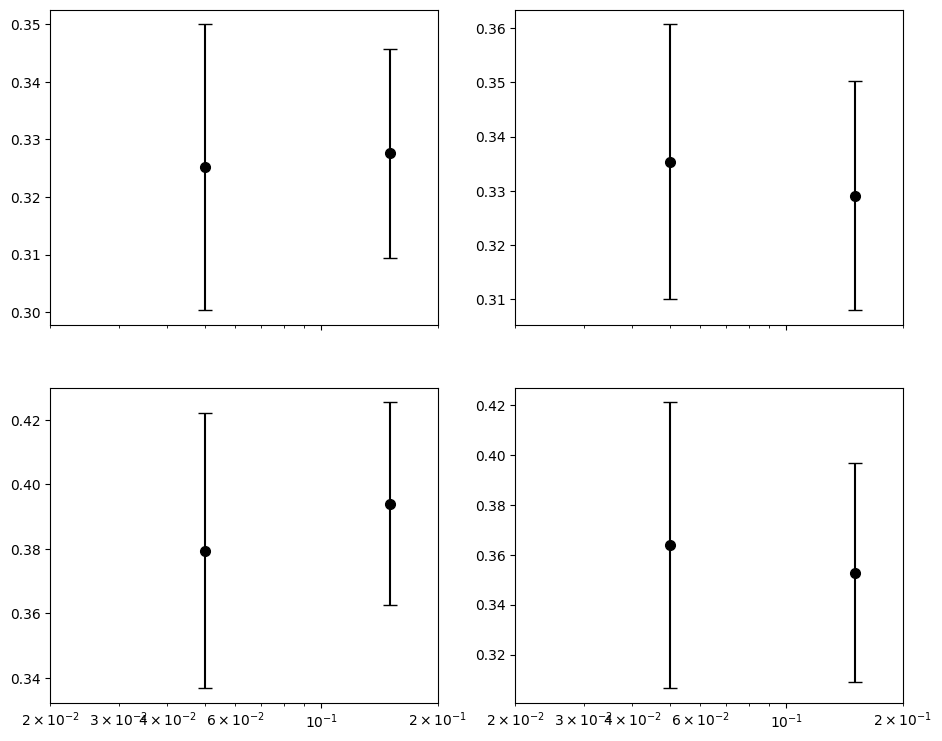

In [5]:
chain_path_kbin = 'chains/des-y3-maglim-2x2pt-anothertest.txt'
samples_kbin = utils.read_samples_from_chain(chain_path=chain_path_kbin, burnin=0)
z_bins = [0.295, 0.467, 0.626, 0.771]

param_names_Jlow = [
    'J_bin_bias--j_low_1', 
    'J_bin_bias--j_low_2', 
    'J_bin_bias--j_low_3', 
    'J_bin_bias--j_low_4'
]

param_names_Jhigh = [
    'J_bin_bias--j_high_1', 
    'J_bin_bias--j_high_2',
    'J_bin_bias--j_high_3', 
    'J_bin_bias--j_high_4'
]

means_low = []
errors_low = []
for p in param_names_Jlow:
    means_low.append(samples_kbin.mean(p))
    errors_low.append(samples_kbin.std(p))

means_high = []
errors_high = []
for p in param_names_Jhigh:
    means_high.append(samples_kbin.mean(p))
    errors_high.append(samples_kbin.std(p))

means_low = np.array(means_low)
errors_low = np.array(errors_low)
means_high = np.array(means_high)
errors_high = np.array(errors_high)


k_low_eff  = 0.05
k_high_eff = 0.15

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    k_data = np.array([k_low_eff, k_high_eff])
    J_data   = np.array([means_low[i], means_high[i]])
    J_err    = np.array([errors_low[i], errors_high[i]])
    ax.errorbar(
        k_data, J_data, yerr=J_err,
        fmt='o', color='black',
        capsize=5, markersize=7,
        label='Measurement'
    )
plt.xscale('log')
plt.xlim(0.02,0.2)
plt.show()

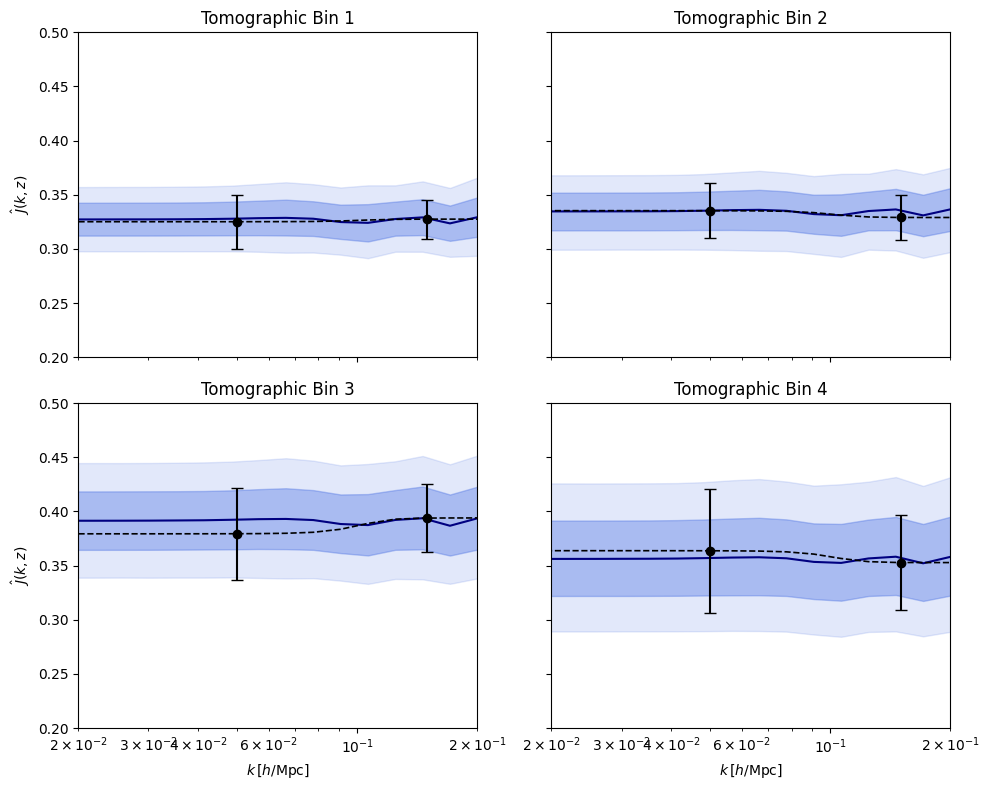

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 物理逻辑 (与 Cosmosis 模块对齐) ---
k_split, delta_k = 0.1, 0.02
def smooth_step(k, vl, vh):
    w = 0.5 * (1.0 - np.tanh((k - k_split) / delta_k))
    return vl * w + vh * (1.0 - w)

# --- 数据提取 ---
data_pca = np.loadtxt("/home/zxw/work/cosmosis_weyl/des-y3-maglim-ini-files/pca_modes.txt")
k_grid, modes = data_pca[:, 0], data_pca[:, 1:4]
s_pca = samples.samples if hasattr(samples, 'samples') else samples
p_J, p_a = s_pca[:, [23, 24, 25, 26]], s_pca[:, [27, 28, 29]]

# --- 画图 ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    
    # 1. PCA 重建 (蓝色阴影)
    J_rec = p_J[:, i][:, None] * (1.0 + p_a @ modes.T)
    pcts = np.percentile(J_rec, [2.5, 16, 50, 84, 97.5], axis=0)
    ax.fill_between(k_grid, pcts[0], pcts[4], color='royalblue', alpha=0.15)
    ax.fill_between(k_grid, pcts[1], pcts[3], color='royalblue', alpha=0.35)
    ax.plot(k_grid, pcts[2], color='navy', lw=1.5)
    
    # 2. k-bin 测量 (黑色阶梯 + 误差棒)
    # 提取均值和标准差
    ml = samples_kbin.mean(f'J_bin_bias--j_low_{i+1}')
    mh = samples_kbin.mean(f'J_bin_bias--j_high_{i+1}')
    sl = samples_kbin.std(f'J_bin_bias--j_low_{i+1}')
    sh = samples_kbin.std(f'J_bin_bias--j_high_{i+1}')
    
    # 绘制连续的平滑阶梯模型
    ax.plot(k_grid, smooth_step(k_grid, ml, mh), color='black', ls='--', lw=1.2)
    
    # 在两个 Bin 的有效中心位置打上测量点
    ax.errorbar([0.05, 0.15], [ml, mh], yerr=[sl, sh], fmt='o', color='black', capsize=4)

    # 坐标轴设置
    ax.set_xscale('log')
    ax.set_xlim(0.02, 0.2)
    ax.set_ylim(0.2, 0.5)
    ax.set_title(f'Tomographic Bin {i+1}')
    if i >= 2: ax.set_xlabel(r'$k \, [h/{\rm Mpc}]$')
    if i % 2 == 0: ax.set_ylabel(r'$\hat{J}(k, z)$')

plt.tight_layout()
plt.savefig('../fig/k_space_withprior.pdf')
plt.show()

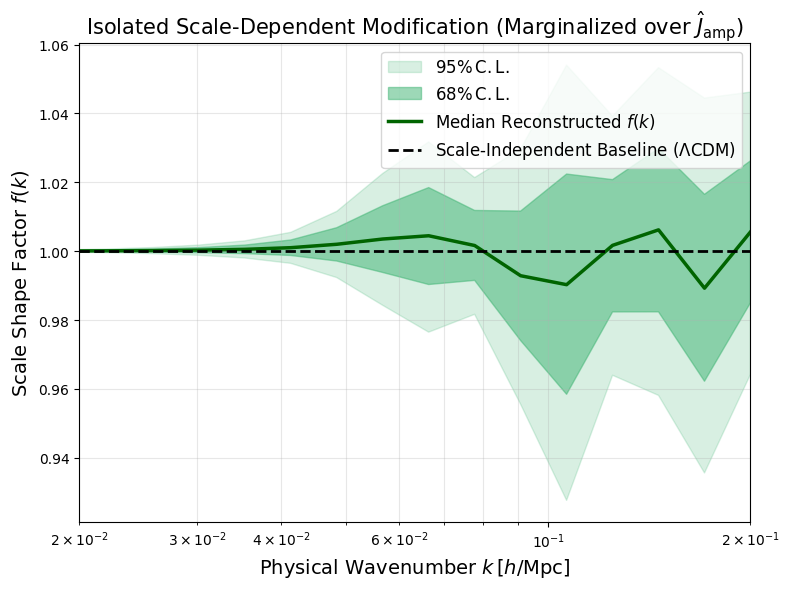

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pure_shape_factor_fk(samples, pca_mode_file, n_modes=3):
    """
    剥离 J_amp 的影响，仅绘制尺度形状因子 f(k) = 1 + sum(alpha_m * e_m(k))。
    这能让你清晰地看到纯粹由 PCA 系数引起的尺度依赖波动和误差带形状。
    """
    if hasattr(samples, 'samples'):
        samples = samples.samples    

    p_alphas = samples[:, [27, 28, 29]]
    
    n_samples = len(samples)

    # ==========================================
    # 2. 载入 PCA 基底 (Eigenmodes)
    # ==========================================
    data_pca = np.loadtxt(pca_mode_file)
    k_grid = data_pca[:, 0]
    modes = data_pca[:, 1:n_modes+1]  # 形状为 (n_k, n_modes)
    
    n_k = len(k_grid)

    # ==========================================
    # 3. 蒙特卡洛重构纯形状因子 f(k)
    # ==========================================
    # 形状：(n_samples, n_k)
    fk_reconstructed = np.zeros((n_samples, n_k))
    
    for i in range(n_samples):
        # 仅计算形状修正: f(k) = 1 + a1*e1 + a2*e2 + a3*e3
        fk_reconstructed[i, :] = 1.0 + np.sum(p_alphas[i, :] * modes, axis=1)

    # ==========================================
    # 4. 计算统计包络 (中位数及置信区间)
    # ==========================================
    fk_median = np.percentile(fk_reconstructed, 50, axis=0)
    fk_68_low = np.percentile(fk_reconstructed, 16, axis=0)
    fk_68_up  = np.percentile(fk_reconstructed, 84, axis=0)
    fk_95_low = np.percentile(fk_reconstructed, 2.5, axis=0)
    fk_95_up  = np.percentile(fk_reconstructed, 97.5, axis=0)

    # ==========================================
    # 5. 绘制精美图像
    # ==========================================
    plt.figure(figsize=(8, 6))
    
    # 绘制置信区间包络
    plt.fill_between(k_grid, fk_95_low, fk_95_up, color='mediumseagreen', alpha=0.2, label=r'$95\%\, {\rm C.L.}$')
    plt.fill_between(k_grid, fk_68_low, fk_68_up, color='mediumseagreen', alpha=0.5, label=r'$68\%\, {\rm C.L.}$')
    
    # 绘制重构的中位数形状
    plt.plot(k_grid, fk_median, color='darkgreen', lw=2.5, label=r'Median Reconstructed $f(k)$')
    
    # 绘制 GR 理论基准 (即没有尺度依赖，f(k) 严格为 1)
    plt.axhline(y=1.0, color='black', linestyle='--', lw=2, label=r'Scale-Independent Baseline ($\Lambda$CDM)')
    
    # 视觉美化设定
    plt.xscale('log')
    # 根据之前对您数据有效范围的分析，限制合理的 k 区间展示
    plt.xlim(0.02, 0.2)
    # plt.ylim(0.99,1.01)
    
    plt.xlabel(r'Physical Wavenumber $k \, [h/{\rm Mpc}]$', fontsize=14)
    plt.ylabel(r'Scale Shape Factor $f(k)$', fontsize=14)
    plt.title(r'Isolated Scale-Dependent Modification (Marginalized over $\hat{J}_{\rm amp}$)', fontsize=15)
    
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    
    plt.show()


plot_pure_shape_factor_fk(samples, pca_mode_file="/home/zxw/work/cosmosis_weyl/des-y3-maglim-ini-files/pca_modes.txt")


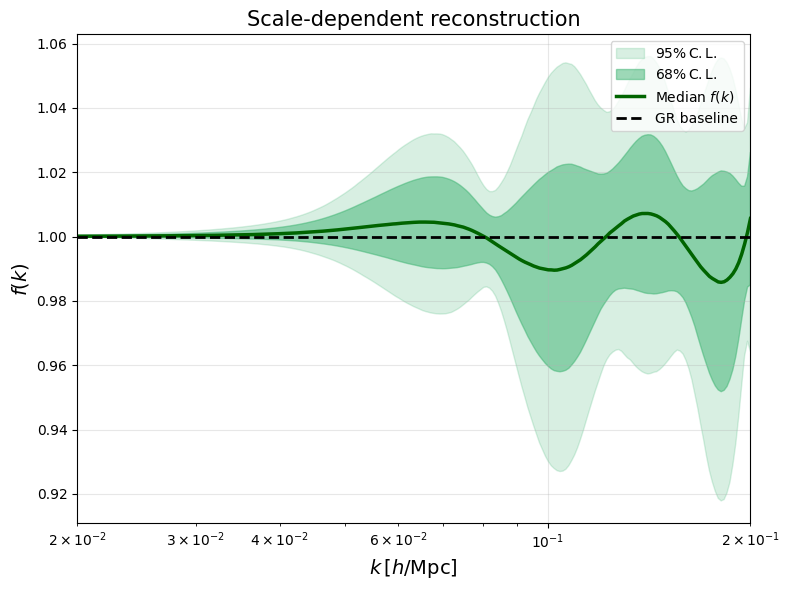

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

def plot_pure_shape_factor_fk_smooth(samples, pca_mode_file, n_modes=3):

    if hasattr(samples, 'samples'):
        samples = samples.samples    

    p_alphas = samples[:, [27, 28, 29]]
    n_samples = len(samples)

    # 读取 PCA 模式
    data_pca = np.loadtxt(pca_mode_file)
    k_grid = data_pca[:, 0]
    modes = data_pca[:, 1:n_modes+1]

    # =====================================
    # 1 生成更密的 k 网格
    # =====================================
    k_dense = np.logspace(np.log10(k_grid.min()),
                          np.log10(k_grid.max()), 300)

    # =====================================
    # 2 对 PCA 模式做 spline 插值
    # =====================================
    modes_dense = np.zeros((len(k_dense), n_modes))

    for m in range(n_modes):
        spline = CubicSpline(k_grid, modes[:, m])
        modes_dense[:, m] = spline(k_dense)

    # =====================================
    # 3 Monte Carlo 重建 f(k)
    # =====================================
    fk_reconstructed = np.zeros((n_samples, len(k_dense)))

    for i in range(n_samples):
        fk_reconstructed[i,:] = 1.0 + np.sum(
            p_alphas[i,:] * modes_dense,
            axis=1
        )

    # =====================================
    # 4 计算统计区间
    # =====================================
    fk_median = np.percentile(fk_reconstructed, 50, axis=0)
    fk_68_low = np.percentile(fk_reconstructed, 16, axis=0)
    fk_68_up  = np.percentile(fk_reconstructed, 84, axis=0)
    fk_95_low = np.percentile(fk_reconstructed, 2.5, axis=0)
    fk_95_up  = np.percentile(fk_reconstructed, 97.5, axis=0)

    # =====================================
    # 5 绘图
    # =====================================
    plt.figure(figsize=(8,6))

    plt.fill_between(k_dense, fk_95_low, fk_95_up,
                     color='mediumseagreen', alpha=0.2,
                     label=r'$95\%\,{\rm C.L.}$')

    plt.fill_between(k_dense, fk_68_low, fk_68_up,
                     color='mediumseagreen', alpha=0.5,
                     label=r'$68\%\,{\rm C.L.}$')

    plt.plot(k_dense, fk_median,
             color='darkgreen', lw=2.5,
             label=r'Median $f(k)$')

    plt.axhline(1.0, color='black', ls='--', lw=2,
                label=r'GR baseline')

    plt.xscale('log')
    plt.xlim(0.02,0.2)
    # plt.ylim(0.99,1.01)

    plt.xlabel(r'$k\,[h/{\rm Mpc}]$',fontsize=14)
    plt.ylabel(r'$f(k)$',fontsize=14)

    plt.title('Scale-dependent reconstruction',fontsize=15)

    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_pure_shape_factor_fk_smooth(
    samples,
    pca_mode_file="/home/zxw/work/cosmosis_weyl/des-y3-maglim-ini-files/pca_modes.txt"
)

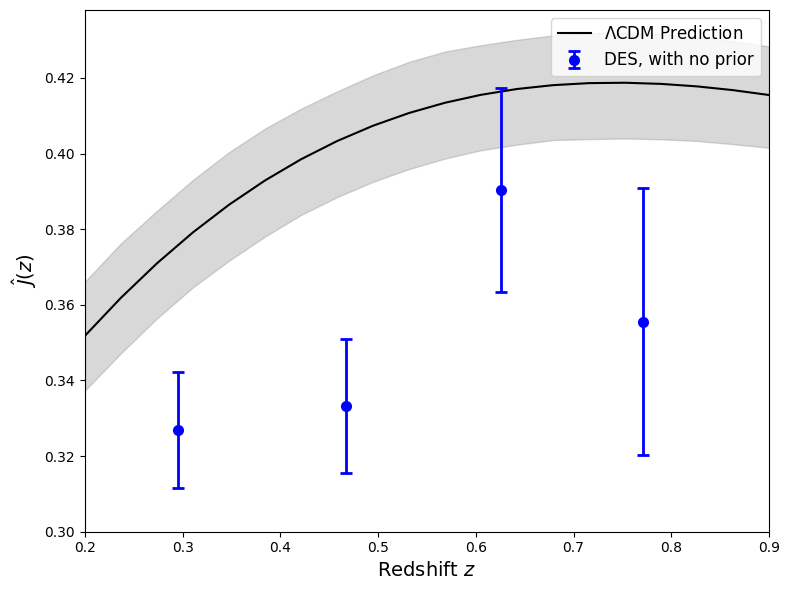

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples
import camb

import utils
# DES MagLim 的 4 个红移分箱
z_bins = np.array([0.295, 0.467, 0.626, 0.771])

# param_names_J = [
#     'J_bin_bias--jhat1', 
#     'J_bin_bias--jhat2', 
#     'J_bin_bias--jhat3', 
#     'J_bin_bias--jhat4'
# ]
param_names_J = [
    'J_bin_bias--j_amp_1', 
    'J_bin_bias--j_amp_2', 
    'J_bin_bias--j_amp_3', 
    'J_bin_bias--j_amp_4'
]

param_Om = '#cosmological_parameters--omega_m'
param_h0 = 'cosmological_parameters--h0'
param_Omb = 'cosmological_parameters--omega_b'
param_ns = 'cosmological_parameters--n_s'
param_As = 'cosmological_parameters--a_s'
param_s8 = 'COSMOLOGICAL_PARAMETERS--SIGMA_8'

pars = camb.CAMBparams()

def get_theory_curve_camb(Om0, h0, Omb, ns, As, z_arr):
    """
    使用 CAMB 计算 Jhat(z) = Omega_m(z) * sigma8(z)
    """
    ombh2 = Omb * h0**2
    omch2 = (Om0 * h0**2) - ombh2
    pars.set_cosmology(H0=h0*100, ombh2=ombh2, omch2=omch2, mnu=0.06, omk=0)
    pars.set_dark_energy(w=-1.0)
 
    pars.InitPower.set_params(ns=ns, As=As)
    
    pars.set_matter_power(redshifts=z_arr, silent=True, kmax=2.0) 
    
    results = camb.get_results(pars)
    
    z_camb = np.array(results.transfer_redshifts)
    s8_camb = np.array(results.get_sigma8())
    
    s8_z = np.interp(z_arr, z_camb[::-1], s8_camb[::-1])

    Om_z = np.array([
        results.get_Omega("cdm", z) + 
        results.get_Omega("baryon", z) + 
        results.get_Omega("nu", z) 
        for z in z_arr
    ])

    return Om_z * s8_z

means = []
errors = []
for p in param_names_J:
    means.append(samples.mean(p))
    errors.append(samples.std(p))
means = np.array(means)
errors = np.array(errors)

z_plot = np.linspace(0.2, 0.9, 20) 

vals_Om = samples[param_Om]
vals_Omb = samples[param_Omb]
vals_h0 = samples[param_h0]
vals_s8 = samples[param_s8]
vals_ns = samples[param_ns]
vals_As = samples[param_As]

theory_curves = []
indices = np.random.choice(len(vals_Om), 200)

for idx in indices:
    om = vals_Om[idx]
    omb = vals_Omb[idx]
    h0 = vals_h0[idx]
    ns = vals_ns[idx]
    As = vals_As[idx]
    
    # 调用 CAMB
    curve = get_theory_curve_camb(om, h0, omb, ns, As, z_plot)
    theory_curves.append(curve)

theory_curves = np.array(theory_curves)
lower_bound = np.percentile(theory_curves, 16, axis=0)
upper_bound = np.percentile(theory_curves, 84, axis=0)
mean_curve = np.mean(theory_curves, axis=0)

fig, ax = plt.subplots(figsize=(8, 6))

ax.fill_between(z_plot, lower_bound, upper_bound, color='gray', alpha=0.3)
ax.plot(z_plot, mean_curve, color='black', lw=1.5, label=r'$\Lambda$CDM Prediction')

ax.errorbar(z_bins, means, yerr=errors, fmt='o', color='blue', 
            capsize=4, elinewidth=2, markeredgewidth=2,
            label='DES, with no prior')

ax.set_xlabel('Redshift $z$', fontsize=14)
ax.set_ylabel(r'$\hat{J}(z)$', fontsize=14)
ax.legend(fontsize=12, loc='upper right')
ax.set_xlim(0.2, 0.9)
ax.set_ylim(ymin = 0.3)

plt.tight_layout()
plt.show()

Removed 0.7 as burn in


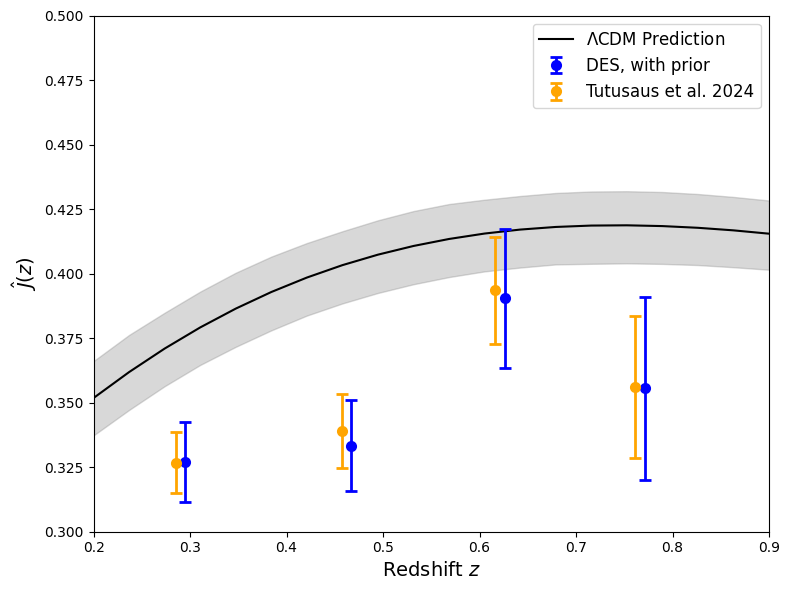

In [10]:
# chain_path2 = '/home/wzx/WorkWork/cosmosis_weyl/chains/des-y3-maglim-2x2pt-polychord_prior_opt.txt' 
chain_path2 = '../chains/des-y3-maglim-2x2pt-polychord_prior_opt.txt' 

samples2 = utils.read_samples_from_chain(chain_path=chain_path2, burnin=0.7)

param_names_J = [
    'J_bin_bias--jhat1', 
    'J_bin_bias--jhat2', 
    'J_bin_bias--jhat3', 
    'J_bin_bias--jhat4'
]

means2 = []
errors2 = []
for p in param_names_J:
    means2.append(samples2.mean(p))
    errors2.append(samples2.std(p))
means2 = np.array(means2)
errors2 = np.array(errors2)

fig, ax = plt.subplots(figsize=(8, 6))

ax.fill_between(z_plot, lower_bound, upper_bound, color='gray', alpha=0.3)
ax.plot(z_plot, mean_curve, color='black', lw=1.5, label=r'$\Lambda$CDM Prediction')

ax.errorbar(z_bins, means, yerr=errors, fmt='o', color='blue', 
            capsize=4, elinewidth=2, markeredgewidth=2,
            label='DES, with prior')

ax.errorbar(z_bins-0.01, means2, yerr=errors2, fmt='o', color='orange', 
            capsize=4, elinewidth=2, markeredgewidth=2,
            label='Tutusaus et al. 2024')

ax.set_xlabel('Redshift $z$', fontsize=14)
ax.set_ylabel(r'$\hat{J}(z)$', fontsize=14)
ax.legend(fontsize=12, loc='upper right')
ax.set_xlim(0.2, 0.9)
ax.set_ylim(ymin = 0.3, ymax=0.5)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import camb
from getdist import loadMCSamples

import utils
# chain_path = '/home/wzx/WorkWork/cosmosis_weyl/MyTest/Mychain_maglim_withprior_radicalcut.txt' 
# samples = utils.read_samples_from_chain(chain_path=chain_path, burnin=0.7)

z_bins = np.array([0.295, 0.467, 0.626, 0.771])

# 链中的参数名
# param_names_J = [
#     'J_bin_bias--jhat1', 
#     'J_bin_bias--jhat2', 
#     'J_bin_bias--jhat3', 
#     'J_bin_bias--jhat4'
# ]
param_names_J = [
    'J_bin_bias--j_amp_1', 
    'J_bin_bias--j_amp_2', 
    'J_bin_bias--j_amp_3', 
    'J_bin_bias--j_amp_4'
]
# 宇宙学参数名
p_om = '#cosmological_parameters--omega_m'
p_h0 = 'cosmological_parameters--h0'
p_omb = 'cosmological_parameters--omega_b'
p_ns  = 'cosmological_parameters--n_s'
p_As = 'cosmological_parameters--a_s'

pars = camb.CAMBparams()

# ================= 核心函数：计算 GR 模板 =================
def get_GR_template(Om0, h0, Omb, ns, As, z_arr):
    """
    使用 CAMB 计算单位 sigma8 下的理论 Jhat 形状。
    返回 T(z) = Omega_m(z) * (D(z)/D(0))
    """
    # 1. 设置宇宙学
    ombh2 = Omb * h0**2
    omch2 = (Om0 * h0**2) - ombh2
    pars.set_cosmology(H0=h0*100, ombh2=ombh2, omch2=omch2, mnu=0.06, omk=0)
    pars.set_dark_energy(w=-1.0)
 
    pars.InitPower.set_params(ns=ns, As=As)
    
    # 2. 设置计算红移 (包含 z=0 用于归一化)
    # 注意：CAMB 内部会自动按红移大小排序（通常是降序）
    z_calc = np.concatenate([[0.0], z_arr])
    pars.set_matter_power(redshifts=z_calc, kmax=1.0, silent=True)
    
    # 3. 获取结果
    results = camb.get_results(pars)
    
    # --- 获取 Omega_m(z) ---
    # get_Omega 支持浮点数 z，这里没问题
    Om_z = np.array([results.get_Omega("cdm", z) + 
                     results.get_Omega("baryon", z) + 
                     results.get_Omega("nu", z) for z in z_arr])
    
    # --- 获取生长因子 D(z) = sigma8(z) / sigma8(0) ---    
    # 1. 获取 CAMB 算好的所有红移 (z_transfer) 和 对应的 sigma8 (s8_transfer)
    z_transfer = np.array(results.transfer_redshifts)
    s8_transfer = np.array(results.get_sigma8())
    
    # 2. 使用插值获取 z=0 和 z=z_arr 处的 sigma8
    # CAMB 的 z_transfer 通常是降序的，np.interp 需要升序的 x，所以用 [::-1] 翻转
    s8_0 = np.interp(0.0, z_transfer[::-1], s8_transfer[::-1])
    s8_z = np.interp(z_arr, z_transfer[::-1], s8_transfer[::-1])    
    D_z = s8_z / s8_0
    
    # 模板 T = Omega_m(z) * D(z)
    return Om_z * D_z
# ================= 主程序 =================

# 1. 加载链
p = samples.getParams()

# 2. 获取 Jhat 的测量误差 (用于加权)
# 原文使用的是整个链统计出来的 std 作为固定的权重分母
J_std = np.array([samples.std(name) for name in param_names_J])
weights = 1.0 / J_std**2

# 3. 稀疏化链 (CAMB比较慢，每 50 步算一次，保证有几千个点即可)
thin = 50
indices = range(0, len(samples.weights), thin)
print(f"Processing {len(indices)} samples...")

derived_s8_list = []

# 4. 遍历链进行拟合
for i in indices:
    # A. 读取该步的宇宙学参数
    om = getattr(p, p_om)[i]
    h0 = getattr(p, p_h0)[i]
    omb = getattr(p, p_omb)[i]
    ns = getattr(p, p_ns)[i]
    As = getattr(p, p_As)[i]
    
    # B. 读取该步的 Jhat 测量值 (作为数据 y)
    J_meas = np.array([getattr(p, name)[i] for name in param_names_J])
    
    # C. 计算该步对应的 GR 模板 (作为模型 x)
    # T_vector 的长度为 4
    T_vector = get_GR_template(om, h0, omb, ns, As, z_bins)
    
    # D. 最小二乘法求 sigma8
    # 公式: s8 = sum(w * x * y) / sum(w * x^2)
    numerator = np.sum(weights * J_meas * T_vector)
    denominator = np.sum(weights * T_vector**2)
    
    s8_fit = numerator / denominator
    derived_s8_list.append(s8_fit)

# ================= 结果输出 =================
derived_s8 = np.array(derived_s8_list)
mean = np.mean(derived_s8)
std = np.std(derived_s8)

print("\n" + "="*40)
print(f"Fit Sigma8(0) from Jhat: {mean:.4f} ± {std:.4f}")
print("="*40)

Processing 666 samples...

Fit Sigma8(0) from Jhat: 0.7419 ± 0.0342


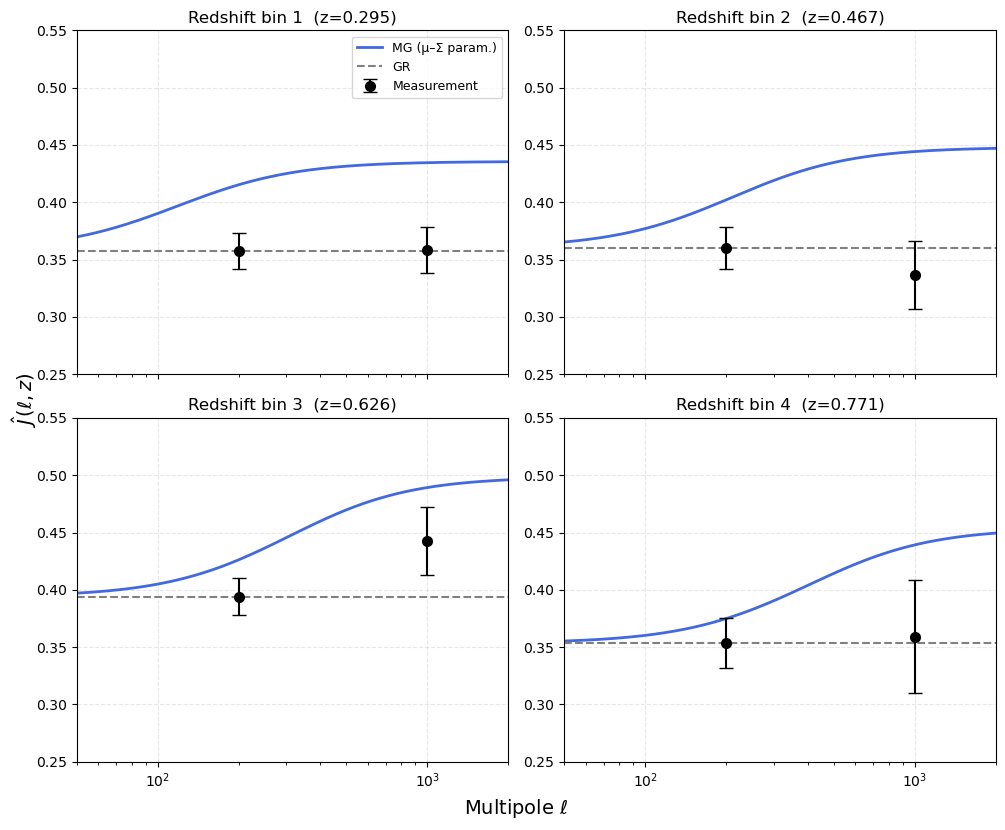

ℓ–k correspondence:
z        k(ℓ=200)       k(ℓ=1000)     
------------------------------------------
0.295    0.2436         1.2154        
0.467    0.1610         0.8032        
0.626    0.1253         0.6253        
0.771    0.1058         0.5279        


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.integrate import quad

# ============================================================
# 0. 基本设置
# ============================================================

# 红移 bin 中心
z_bins = [0.295, 0.467, 0.626, 0.771]

# 有效 ℓ
ell_low_eff  = 200.0
ell_high_eff = 1000.0

# 宇宙学
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
h = 0.7

# ============================================================
# 1. 从 samples 中提取 Ĵ
# ============================================================

param_names_Jlow = [
    'J_bin_bias--j_low_1',
    'J_bin_bias--j_low_2',
    'J_bin_bias--j_low_3',
    'J_bin_bias--j_low_4'
]

param_names_Jhigh = [
    'J_bin_bias--j_high_1',
    'J_bin_bias--j_high_2',
    'J_bin_bias--j_high_3',
    'J_bin_bias--j_high_4'
]

means_low, errors_low = [], []
means_high, errors_high = [], []

for p in param_names_Jlow:
    means_low.append(samples.mean(p))
    errors_low.append(samples.std(p))

for p in param_names_Jhigh:
    means_high.append(samples.mean(p))
    errors_high.append(samples.std(p))

means_low   = np.array(means_low)
errors_low  = np.array(errors_low)
means_high  = np.array(means_high)
errors_high = np.array(errors_high)

# ============================================================
# 2. ℓ → k 转换（严格）
# ============================================================

def ell_to_k(ell, z):
    chi = cosmo.comoving_distance(z).value * h  # Mpc/h
    return (ell + 0.5) / chi                    # h/Mpc

# ============================================================
# 3. μ–Σ 参数化（f(R)-like，有物理意义的 toy model）
# ============================================================

def mu_fR(k, z, k_c0=0.1):
    """
    有效 μ(k,z)，模仿 f(R) 的 Yukawa 结构
    """
    a = 1.0 / (1.0 + z)
    k_c = k_c0 * a**(-1.5)   # Compton scale 演化
    return 1.0 + (1.0/3.0) * k**2 / (k**2 + k_c**2)

# def Sigma_fR(k, z):
#     """
#     f(R) 中透镜势近似不变
#     """
#     return 1.0

def Sigma_fR(k, z, k_c0=0.1):
    a = 1.0 / (1.0 + z)
    k_c = k_c0 * a**(-1.5)
    return 1.0 + (1.0/6.0) * k**2 / (k**2 + k_c**2)

# ============================================================
# 4. 从 μ 重构增长因子比值（关键：不是 sqrt(mu)）
# ============================================================

def D_ratio_from_mu(mu_func, k, z):
    """
    D_MG / D_GR using growth-rate based approximation
    """
    def integrand(zp):
        mu = mu_func(k, zp)
        delta_mu = 0.5 * (mu - 1.0)
        return delta_mu / (1.0 + zp)

    integral, _ = quad(integrand, 0.0, z, limit=200)
    return np.exp(integral)

# ============================================================
# 5. Ĵ 比值：这是唯一需要的理论输入
# ============================================================

def J_ratio_fR(ell, z):
    k = ell_to_k(ell, z)
    D_ratio = D_ratio_from_mu(mu_fR, k, z)
    Sigma = Sigma_fR(k, z)
    return D_ratio * Sigma

# ============================================================
# 6. 作图准备
# ============================================================

ell_plot = np.logspace(np.log10(50), np.log10(2000), 200)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

# ============================================================
# 7. 主循环：每个红移 bin
# ============================================================

for i, ax in enumerate(axes):
    z_i = z_bins[i]

    # GR 基准（用低 ℓ 的 Ĵ 作为归一）
    J_GR = means_low[i]

    # 理论曲线
    J_ratio = np.array([J_ratio_fR(l, z_i) for l in ell_plot])
    ax.plot(
        ell_plot,
        J_GR * J_ratio,
        color='royalblue',
        lw=2,
        label='MG (μ–Σ param.)'
    )

    # GR 参考线
    ax.axhline(J_GR, color='gray', ls='--', lw=1.5, label='GR')

    # 数据点
    ell_data = np.array([ell_low_eff, ell_high_eff])
    J_data   = np.array([means_low[i], means_high[i]])
    J_err    = np.array([errors_low[i], errors_high[i]])

    ax.errorbar(
        ell_data, J_data, yerr=J_err,
        fmt='o', color='black',
        capsize=5, markersize=7,
        label='Measurement'
    )

    # 图形设置
    ax.set_xscale('log')
    ax.set_xlim(50, 2000)
    ax.set_ylim(0.25, 0.55)
    ax.grid(alpha=0.3, ls='--')
    ax.set_title(f'Redshift bin {i+1}  (z={z_i:.3f})')

    if i == 0:
        ax.legend(fontsize=9)

# ============================================================
# 8. 全局标签
# ============================================================

fig.text(0.5, 0.04, r'Multipole $\ell$', ha='center', fontsize=14)
fig.text(0.04, 0.5, r'$\hat J(\ell, z)$', va='center',
         rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()

# ============================================================
# 9. 输出 ℓ–k 对应（检查用）
# ============================================================

print("ℓ–k correspondence:")
print("="*42)
print(f"{'z':<8} {'k(ℓ=200)':<14} {'k(ℓ=1000)':<14}")
print("-"*42)
for z in z_bins:
    print(f"{z:<8.3f} {ell_to_k(200,z):<14.4f} {ell_to_k(1000,z):<14.4f}")
print("="*42)


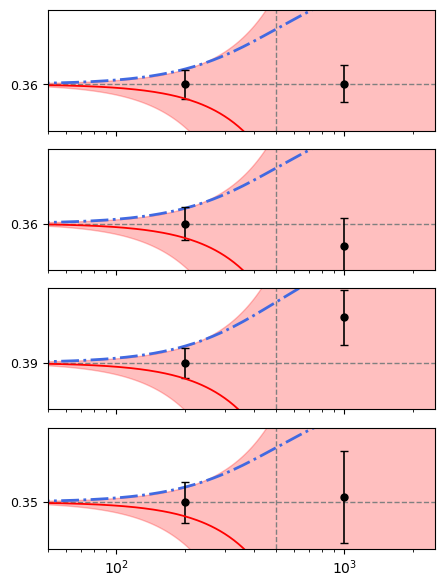

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(
    4, 1,
    figsize=(5.0, 7.0),   # <<< 更扁更窄，适合单栏
    sharex=True,
    gridspec_kw={'hspace': 0.15}  # 减小间距，像“表格行”
)

ell_plot = np.logspace(1.5, 3.5, 200)

def get_phenom_curve(Jhatbase , A_val, ell):
    return Jhatbase * (1.0 + A_val * (ell / 500)**2)

A_std = 0.54
A_val = -0.27

for i, ax in enumerate(axes):

    # --- baseline ---
    j_baseline = means_low[i]
    ax.axhline(y=j_baseline, color='gray', linestyle='--', linewidth=1.0)
    ax.axvline(x=500,color='gray', linestyle='--', linewidth=1.0)
    y_mg = fR_prediction_mock(ell_plot, j_baseline) 
    ax.plot(ell_plot, y_mg, color='royalblue', linestyle='-.', linewidth=2, 
            label=r'$f(R)$ Gravity Prediction')

    # --- errorbar measurements ---
    ax.errorbar(data_ell[i], data_J[i], yerr=data_err[i],
                fmt='o', color='black',
                capsize=3, markersize=5, elinewidth=1.2)

    # --- scale dependent J curve ---
    curve = get_phenom_curve(j_baseline, A_val, ell_plot)
    upper = get_phenom_curve(j_baseline, A_val - A_std, ell_plot)
    lower = get_phenom_curve(j_baseline, A_val + A_std, ell_plot)

    ax.plot(ell_plot, curve, color='red', linewidth=1.3)
    ax.fill_between(ell_plot, lower, upper, color='red', alpha=0.25)

    # ============= 关键美化：让 panel 很扁 =============
    ax.set_ylim(j_baseline - 0.05, j_baseline + 0.08) 
    ax.set_yticks([j_baseline]) 
    ax.set_yticklabels([f"{j_baseline:.2f}"])
    ax.tick_params(axis='y', labelsize=9)

    ax.set_xscale('log')
    ax.set_xlim(50, 2500)



In [10]:
param_names_J = [
    'J_bin_bias--j_low_1', 
    'J_bin_bias--j_low_2', 
    'J_bin_bias--j_low_3', 
    'J_bin_bias--j_low_4'
]

# 宇宙学参数名
param_Om = '#cosmological_parameters--omega_m'
param_h = 'cosmological_parameters--h0'
param_ob = 'cosmological_parameters--omega_b'
param_ns = 'cosmological_parameters--n_s'
param_As = 'cosmological_parameters--a_s'
param_s8 = 'COSMOLOGICAL_PARAMETERS--SIGMA_8'

Omega_m_mean = samples.mean(param_Om)
h_mean = samples.mean(param_h)
Omega_b_mean = samples.mean(param_ob)
ns_mean = samples.mean(param_ns)
As_mean = samples.mean(param_As)
sigma8_mean = samples.mean(param_s8)

print("\n宇宙学参数均值:")
print(f"  Ω_m = {Omega_m_mean:.4f}")
print(f"  h = {h_mean:.4f}")
print(f"  Ω_b = {Omega_b_mean:.4f}")
print(f"  n_s = {ns_mean:.4f}")
print(f"  A_s = {As_mean:.3e}")
print(f"  σ_8 = {sigma8_mean:.4f}")


宇宙学参数均值:
  Ω_m = 0.3213
  h = 0.6789
  Ω_b = 0.0482
  n_s = 0.9704
  A_s = 2.245e-09
  σ_8 = 0.8649


In [9]:
import pandas as pd
import numpy as np
import utils

print(samples.getTable(limit=1).tableTex())

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$#cosmological_parameters--omega_m$} & $0.324\pm 0.015            $\\

{\boldmath$cosmological_parameters--h0$} & $0.673\pm 0.015            $\\

{\boldmath$cosmological_parameters--omega_b$} & $0.0488\pm 0.0015          $\\

{\boldmath$cosmological_parameters--n_s$} & $0.9589\pm 0.0092          $\\

{\boldmath$cosmological_parameters--a_s$} & $\left(\,2.11^{+0.12}_{-0.14}\,\right)\cdot 10^{-9}$\\

{\boldmath$shear_calibration_parameters--m1$} & $-0.0051^{+0.0090}_{-0.0072}$\\

{\boldmath$shear_calibration_parameters--m2$} & $-0.0158\pm 0.0076         $\\

{\boldmath$shear_calibration_parameters--m3$} & $-0.0073^{+0.0085}_{-0.0070}$\\

{\boldmath$shear_calibration_parameters--m4$} & $-0.0068^{+0.0051}_{-0.0037}$\\

{\boldmath$wl_photoz_errors--bias_1$} & $-0.0002\pm 0.0086         $\\

{\boldmath$wl_photoz_errors--bias_2$} & $-0.0076\pm 0.0060         $\\

{\boldmath$wl_photoz_errors--bias_3$} & $-0.0032\pm 0.0071   

Data Vector Shape: (8,)
Cov Matrix Shape: (8, 8)
Data Vector: [0.35763036 0.35838874 0.36023639 0.33634953 0.39400428 0.44295112
 0.35345157 0.3590468 ]
Covariance Matrix:
 [[ 2.40881992e-04  1.88561066e-04 -3.17247970e-05 -4.51750826e-05
   1.00445572e-05 -6.86014781e-06 -3.04781311e-05  6.07295087e-05]
 [ 1.88561066e-04  3.92295400e-04 -1.35454530e-04 -2.49653887e-04
  -4.65193560e-05 -9.38861322e-05 -1.17337394e-05 -1.07678361e-04]
 [-3.17247970e-05 -1.35454530e-04  3.30248303e-04  2.67622251e-04
   1.23836043e-04  7.43611383e-05 -8.40460432e-05  9.02708692e-05]
 [-4.51750826e-05 -2.49653887e-04  2.67622251e-04  8.98728941e-04
   1.45940839e-04  1.41091470e-04 -3.94854663e-06  2.56598846e-05]
 [ 1.00445572e-05 -4.65193560e-05  1.23836043e-04  1.45940839e-04
   2.65420284e-04  2.89546287e-05  2.77233817e-05  1.02897135e-04]
 [-6.86014781e-06 -9.38861322e-05  7.43611383e-05  1.41091470e-04
   2.89546287e-05  8.81304991e-04 -2.73469475e-04 -7.93258165e-04]
 [-3.04781311e-05 -1.17337394

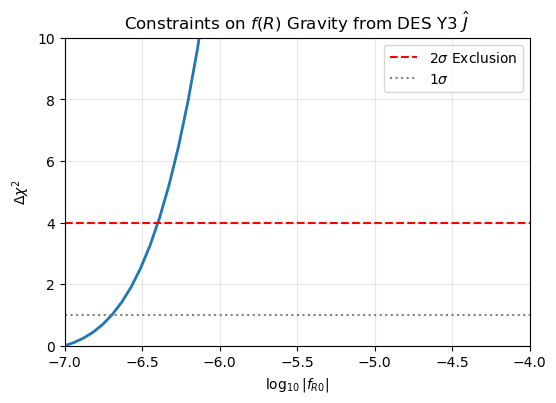

In [7]:
import numpy as np
from getdist import loadMCSamples

# 2. 定义参数名
params = [
    'J_bin_bias--j_low_1', 'J_bin_bias--j_high_1',
    'J_bin_bias--j_low_2', 'J_bin_bias--j_high_2',
    'J_bin_bias--j_low_3', 'J_bin_bias--j_high_3',
    'J_bin_bias--j_low_4', 'J_bin_bias--j_high_4'
]

# 第一步：把参数名转换为整数索引
# samples.index 是一个字典，可以通过名字查到它在链中的第几列
param_indices = [samples.index[p] for p in params]

# 第二步：获取所有参数的均值，然后按索引提取
all_means = samples.getMeans()
mean_vec = all_means[param_indices]

# 第三步：获取协方差矩阵
# getCov() 默认返回所有参数的矩阵，我们需要根据索引切片
full_cov = samples.getCov()
# 使用 np.ix_ 进行行列切片，只取这 8x8 的部分
cov_mat = full_cov[np.ix_(param_indices, param_indices)]

# 计算逆矩阵（为下一步做准备）
inv_cov = np.linalg.inv(cov_mat)

print("Data Vector Shape:", mean_vec.shape) # 应该是 (8,)
print("Cov Matrix Shape:", cov_mat.shape)   # 应该是 (8, 8)
print("Data Vector:", mean_vec)
print("Covariance Matrix:\n", cov_mat)

from scipy.integrate import odeint
import camb

# === 设置基准宇宙学参数 (使用你 MCMC 的最佳拟合值) ===
Om0 = 0.315
h = 0.673
sigma8_0_GR = 0.80  # 注意：这是 GR 的基准 sigma8

# 红移
z_bins = np.array([0.295, 0.467, 0.626, 0.771])

# 有效 k 值 (High Bin 的代表尺度)
# 因为你是从 k=0.3 开始切的，代表值可以取 0.5 到 1.0 之间
k_high_eff = 0.6  # h/Mpc

# --- f(R) 理论计算核心 ---
def get_mu_sigma_fR(k, a, fR0):
    # Hu-Sawicki f(R) (n=1)
    # 质量平方 m^2 ~ (H0^2 / |fR0|) * ...
    # 简化近似：在大尺度结构中背景场导致质量演化
    # m(a)^2 approx H0^2 * (Omega_m + 4 Omega_L) / (2 |fR0|) * (Omega_m a^-3 + 4 Omega_L)^(n+1)
    # 这里用简单的汤川形式示意，严谨计算需用 MGCAMB 的公式
    # 简单版：Compton 尺度 lambda_C^2 = 3 |fR0| / 2 * (Hubble/H0)^-2
    
    H_sq_ratio = Om0 * a**(-3) + (1-Om0) # E^2
    lambda_C_sq = 1.5 * abs(fR0) / H_sq_ratio * (2997.9)**2 # (c/H0)^2 in Mpc/h units approx
    
    # Q = 2 * k^2 * lambda_C^2
    Q = 2 * k**2 * lambda_C_sq
    
    # mu = (1 + 4Q/3) / (1 + Q)
    mu = (1 + 4*Q/3) / (1 + Q)
    # sigma = (1 + 2Q/3) / (1 + Q) -- 但 f(R) 小尺度通常 sigma->1 (因为 eta 变了)
    # 然而，这里的 Sigma 是 Weyl / Density。
    # 准确公式：Sigma = mu * (1 + eta) / 2
    # eta = (1 + 2Q/3) / (1 + 4Q/3)
    # 乘起来 Sigma = 1 + Q/3 ... 不对，Sigma 在 f(R) 小尺度确实趋于 1。
    
    Sigma = 1.0 # f(R) 的几何因子在小尺度接近 1
    
    return mu, Sigma

def growth_ode_fR(y, lna, k, fR0):
    delta, d_delta = y
    a = np.exp(lna)
    E = np.sqrt(Om0 * a**(-3) + (1-Om0))
    Om_z = Om0 * a**(-3) / E**2
    dlnH = -1.5 * Om_z
    
    mu, _ = get_mu_sigma_fR(k, a, fR0)
    
    friction = 2.0 + dlnH
    source = 1.5 * Om_z * mu
    
    return [d_delta, -friction*d_delta + source*delta]

def predict_vector_fR(fR0):
    """
    输入 fR0，输出 8 个预测值
    """
    preds = []
    
    # 积分设置
    lna_grid = np.linspace(np.log(1e-3), 0, 200)
    
    # 1. 先算 GR 基准 (用于归一化)
    sol_GR = odeint(growth_ode_fR, [1e-3, 1e-3], lna_grid, args=(1e-5, 0.0)) # fR0=0
    D_GR_all = np.interp(np.log(1/(1+z_bins)), lna_grid, sol_GR[:,0])
    D_GR_0 = sol_GR[-1, 0]
    
    # 2. 算 fR (针对 k_high)
    sol_MG = odeint(growth_ode_fR, [1e-3, 1e-3], lna_grid, args=(k_high_eff, fR0))
    D_MG_all = np.interp(np.log(1/(1+z_bins)), lna_grid, sol_MG[:,0])
    
    # 3. 填充 8 个点
    for i in range(4):
        z = z_bins[i]
        
        # 计算背景项
        Ez = np.sqrt(Om0 * (1+z)**3 + (1-Om0))
        Om_z = Om0 * (1+z)**3 / Ez**2
        
        # --- Low Point (GR) ---
        # J = Om(z) * sigma8_GR(z)
        s8_gr_z = sigma8_0_GR * (D_GR_all[i] / D_GR_0)
        J_low = Om_z * s8_gr_z
        preds.append(J_low)
        
        # --- High Point (MG) ---
        # J = Sigma * Om(z) * sigma8_MG(z)
        # Ratio = D_MG(z) / D_GR(z)
        growth_boost = D_MG_all[i] / D_GR_all[i]
        
        # 对于 f(R), Sigma ~ 1
        J_high = J_low * growth_boost 
        preds.append(J_high)
        
    return np.array(preds)

# 扫描范围：log10(fR0) 从 -7 (GR) 到 -4 (Strong MG)
fR0_log_values = np.linspace(-7, -4, 50)
chi2_values = []

for val in fR0_log_values:
    fR0 = 10**val
    
    # 计算理论向量
    T_vec = predict_vector_fR(fR0)
    
    # 计算 Chi2
    delta = mean_vec - T_vec
    chi2 = np.dot(delta.T, np.dot(inv_cov, delta))
    
    chi2_values.append(chi2)

chi2_values = np.array(chi2_values)

# 转换为 Delta Chi2
min_chi2 = np.min(chi2_values) # 或者是 GR 的 chi2
delta_chi2 = chi2_values - min_chi2

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(fR0_log_values, delta_chi2, lw=2)

# 画 2 sigma 线 (95% CL, Delta Chi2 = 4)
plt.axhline(4.0, color='r', linestyle='--', label=r'$2\sigma$ Exclusion')
plt.axhline(1.0, color='gray', linestyle=':', label=r'$1\sigma$')

plt.xlabel(r'$\log_{10} |f_{R0}|$')
plt.ylabel(r'$\Delta \chi^2$')
plt.title(r'Constraints on $f(R)$ Gravity from DES Y3 $\hat{J}$')
plt.ylim(0, 10)
plt.xlim(-7, -4)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from scipy.integrate import odeint, simps
from scipy.interpolate import interp1d

# ==========================================
# 1. 物理模型设定
# ==========================================
# 宇宙学参数 (DES Y3 Best Fit 或 Planck)
H0 = 67.36
h = H0 / 100.0
ombh2 = 0.02237
omch2 = 0.1200
mnu = 0.06
Om0 = (ombh2 + omch2) / h**2  # 近似，CAMB会自动算得更准

# f(R) 参数
fR0_val = 1e-5  # |fR0|
n_fR = 1

# ==========================================
# 2. 获取严谨的背景演化 (使用 CAMB)
# ==========================================
def get_background_functions(kmax=10.0):
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=mnu, omk=0)
    pars.set_dark_energy(w=-1.0)
    pars.InitPower.set_params(ns=0.965, As=2.1e-9)
    
    # 只需要背景，但我们需要覆盖到高红移
    pars.set_matter_power(redshifts=[0.], kmax=kmax, silent=True)
    results = camb.get_results(pars)
    
    # 生成插值表用的红移 (从 z=100 到 z=0)
    z_table = np.geomspace(100.0, 0.001, 500)
    z_table = np.append(z_table, 0.0)
    a_table = 1.0 / (1.0 + z_table)
    
    # 1. H(a) / H0
    E_table = results.hubble_parameter(z_table) / H0
    
    # 2. Omega_m(a) (物理物质密度参数)
    # 注意：严谨计算生长时，源项取决于 clustering matter (通常不含中微子)
    # 这里我们取 (cdm + baryon)
    rho_c = results.get_rho_c(z=0) # 临界密度
    
    # 获取各组分物理密度 (physical density parameter)
    # CAMB get_Omega 返回的是 Omega_i(z)
    Om_cb_table = np.array([results.get_Omega("cdm", z) + results.get_Omega("baryon", z) for z in z_table])
    
    # 构造插值函数
    # 对 lna 插值比较平滑
    lna_table = np.log(a_table)
    
    E_interp = interp1d(lna_table, E_table, kind='cubic')
    Om_cb_interp = interp1d(lna_table, Om_cb_table, kind='cubic')
    
    # 还需要 GR 的 P(k, z=0) 来计算 sigma8
    # 使用 CAMB 的非线性关闭模式
    pars.NonLinear = camb.model.NonLinear_none
    pk_gr_lin = results.get_matter_power_interpolator(nonlinear=False)
    
    return E_interp, Om_cb_interp, pk_gr_lin, results

# 初始化背景函数
E_func, Om_cb_func, Pk_GR_func, camb_results = get_background_functions()

# ==========================================
# 3. 定义修正引力参数 (Hu-Sawicki f(R))
# ==========================================
def get_mu_sigma_fR(k, a, fR0):
    # k: h/Mpc, a: scale factor
    # 严格的 f(R) 质量项计算
    # mass^2 = (H0^2 / 2|fR0|) * ( (Omega_m a^-3 + 4 Omega_L) / (Omega_m + 4 Omega_L) )^(n+2) ... 近似
    # 这里使用准静态近似下的标准 Yukawa 形式
    
    # 转换 k 单位: CAMB 内部 k 是 Mpc^-1, 但我们输入通常是 h/Mpc
    # 这里假设输入 k 是 h/Mpc
    k_phys = k / h # 转为 Mpc^-1 比较安全，或者保持 h/Mpc 一致性
    
    # Compton 尺度 (Mpc/h)
    # lambda_C^2 ~ |fR0| / H^2
    # 这是一个简化，严谨需用 MGCAMB 公式，但对于探测尺度依赖，这个近似足够捕捉 k^2 特征
    # 下面使用最常用的 HS 模型近似：
    Om_m = Om0 # 今天的
    Om_L = 1 - Om_m
    background_term = (Om_m * a**(-3) + 4 * Om_L)
    
    # c = 2997.9 Mpc/h * h/Mpc ?? 
    # 在 h/Mpc 单位下，H0 ~ 1/3000
    c_H0_sq = (2997.9)**2 # (c/H0)^2 in (Mpc/h)^2
    
    m_sq_inv = 3 * abs(fR0) * c_H0_sq * (background_term)**(-(n_fR+2)) * (Om_m + 4*Om_L)**(n_fR+1)
    
    # Q = 2 k^2 / (a^2 m^2) = 2 k^2 * lambda_C^2
    Q = 2 * k**2 * m_sq_inv 
    
    mu = (1 + 4*Q/3) / (1 + Q)
    Sigma = (1 + 2*Q/3) / (1 + Q) # 此时 Sigma 会随 k 变化
    
    # 你的论文中如果使用 Sigma=1，可以在这里强制 Sigma=1
    # Sigma = 1.0 
    
    return mu, Sigma

# ==========================================
# 4. 严谨的生长方程求解器
# ==========================================
def solve_growth_for_k(k, lna_grid, fR0):
    """
    对特定的 k 解微分方程
    """
    def ode(y, lna):
        delta, d_delta = y
        a = np.exp(lna)
        
        # 1. 获取背景量 (来自 CAMB 插值)
        E = E_func(lna)
        Om_cb = Om_cb_func(lna)
        
        # 2. 计算摩擦项系数 (2 + dlnH/dlna)
        # dlnH/dlna = (dH/da) * a / H
        # 我们可以用数值微分 E_func 得到，或者使用近似公式
        # 为严谨，使用近似：E^2 = Om_m a^-3 + Om_L + Om_r a^-4
        # 2 E dE/da = -3 Om_m a^-4 - 4 Om_r a^-5
        # dlnE/dlna = (a/E) * (-1.5 Om_m a^-4 - 2 Om_r a^-5) / 2 ...
        # 这里用 Om_cb 近似物质项主导: dlnH/dlna approx -1.5 * Om_cb (忽略辐射)
        dlnH_dlna = -1.5 * Om_cb 
        
        friction = 2.0 + dlnH_dlna
        
        # 3. 获取 MG 参数
        mu, _ = get_mu_sigma_fR(k, a, fR0)
        
        # 4. 源项
        source = 1.5 * Om_cb * mu
        
        return [d_delta, -friction*d_delta + source*delta]

    # 初始条件 (高红移 GR)
    y0 = [np.exp(lna_grid[0]), np.exp(lna_grid[0])]
    
    sol = odeint(ode, y0, lna_grid)
    return sol[:, 0] # 返回 delta(z)

# ==========================================
# 5. 严谨计算 Sigma8 和 Jhat
# ==========================================
def calculate_observables_rigorous(target_z_values, fR0):
    """
    计算给定红移处的 Jhat 和 sigma8
    """
    print(f"Calculating for fR0 = {fR0}...")
    
    # 积分网格
    z_ini = 100.0
    lna_grid = np.linspace(np.log(1/(1+z_ini)), 0.0, 500)
    z_grid = 1/np.exp(lna_grid) - 1
    
    # 1. 我们需要对 k 进行积分来算 sigma8
    # k 范围: 1e-4 到 10 h/Mpc
    k_vals = np.logspace(-4, 1, 100)
    
    # 存储不同 k 的生长因子比率 T_MG(k, z) = delta_MG(k, z) / delta_GR(k, 0)
    growth_ratio_grid = np.zeros((len(k_vals), len(lna_grid)))
    sigma_grid = np.zeros((len(k_vals), len(lna_grid)))
    
    # 2. 先算 GR 参考生长 (fR0 = 0)
    # 用于归一化
    delta_GR_all = solve_growth_for_k(1e-4, lna_grid, 0.0) # 低 k 代表线性
    delta_GR_0 = delta_GR_all[-1]
    
    # 3. 循环计算每个 k 的 MG 生长
    for i, k in enumerate(k_vals):
        delta_MG = solve_growth_for_k(k, lna_grid, fR0)
        
        # 定义传递函数比率: T(k, z)
        # P_MG(k, z) = P_GR(k, 0) * (delta_MG(z)/delta_GR(0))^2
        # 注意：这里假设初始条件在高红移是一样的
        growth_ratio_grid[i, :] = delta_MG / delta_GR_0
        
        # 同时记录 Sigma(k, z)
        for j, a in enumerate(np.exp(lna_grid)):
            _, s = get_mu_sigma_fR(k, a, fR0)
            sigma_grid[i, j] = s

    # 4. 计算 sigma8(z) 和 Jhat(z)
    # 严谨公式: sigma8^2(z) = int P_MG(k, z) W^2(kR) dk
    R = 8.0
    
    Jhat_results = []
    
    # 获取 CAMB 的 GR 功率谱 P(k, z=0)
    Pk_GR_0 = Pk_GR_func.P(0.0, k_vals)
    
    for z_target in target_z_values:
        # 找到最近的 grid index
        idx = np.argmin(np.abs(z_grid - z_target))
        
        # 该红移处的 P_MG(k)
        # P_MG(k) = P_GR(0) * ratio(k)^2
        ratio_k = growth_ratio_grid[:, idx]
        Pk_MG = Pk_GR_0 * ratio_k**2
        
        # 积分计算 sigma8_MG(z)
        window = 3 * (np.sin(k_vals*R) - k_vals*R*np.cos(k_vals*R)) / (k_vals*R)**3
        integrand = k_vals**2 * Pk_MG * window**2 / (2 * np.pi**2)
        s8_sq = simps(integrand, np.log(k_vals)) # log 积分更准
        s8_MG = np.sqrt(s8_sq)
        
        # 计算 Jhat(z)
        # 严谨公式: Jhat = Omega_m(z) * Sigma_eff(z) * sigma8_MG(z)
        # 问题: Sigma 是 k 依赖的，怎么变成标量？
        # 在观测上，Jhat 是对 k 的加权平均。
        # 简单处理：取 k 对应 ell~500-1000 处的 Sigma 值，或者加权。
        # 这里我们取 k_eff = 0.5 处的 Sigma (对应你的测量敏感区)
        # 或者更严谨：Jhat 应该也是一个 k 的函数 Jhat(k) = Sigma(k)*Om*sigma8_MG
        # 如果你要输出标量 Jhat，通常指的是大尺度的基准，或者是某个 k 的值
        
        # 这里我们计算 "Effective Jhat" 在 k=0.5 处
        k_eff = 0.5
        _, Sigma_eff = get_mu_sigma_fR(k_eff, 1/(1+z_target), fR0)
        
        Om_z = Om_cb_func(np.log(1/(1+z_target)))
        
        J_val = Sigma_eff * Om_z * s8_MG
        Jhat_results.append(J_val)
        
    return np.array(Jhat_results)

# ==========================================
# 6. 执行计算
# ==========================================
z_bins = np.array([0.295, 0.467, 0.626, 0.771])

# 计算 f(R) 模型
J_fR = calculate_observables_rigorous(z_bins, fR0=1e-5)

# 计算 GR 模型
J_GR = calculate_observables_rigorous(z_bins, fR0=0.0)

print("Redshift:", z_bins)
print("Jhat (GR):", J_GR)
print("Jhat (fR):", J_fR)
print("Ratio:", J_fR/J_GR)

ImportError: cannot import name 'simps' from 'scipy.integrate' (/home/wzx/WorkWork/cosmosis_weyl/cosmosisenv/env/lib/python3.13/site-packages/scipy/integrate/__init__.py)